TASK-2: STOCK PRICE PREDICTION 

THIS PROJECT PREDICTS FUTURE STOCK PRICES USING HISTORICAL DATA OF 5 STOCKS. I USED LINEAR REGRESSION MODEL WITH LAG FEATURES AND EVALUATED USING MAE, RMSE AND R² SCORE.

1. Importing Libraries 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

2. Loading Data

In [17]:
df = pd.read_csv('stock_data.csv', index_col=0)
df.index = pd.to_datetime(df.index)
df.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


3. Checking Data Info

In [18]:
df.shape

(365, 5)

In [19]:
df.isnull().sum()

Stock_1    0
Stock_2    0
Stock_3    0
Stock_4    0
Stock_5    0
dtype: int64

4. Ploting All Stocks

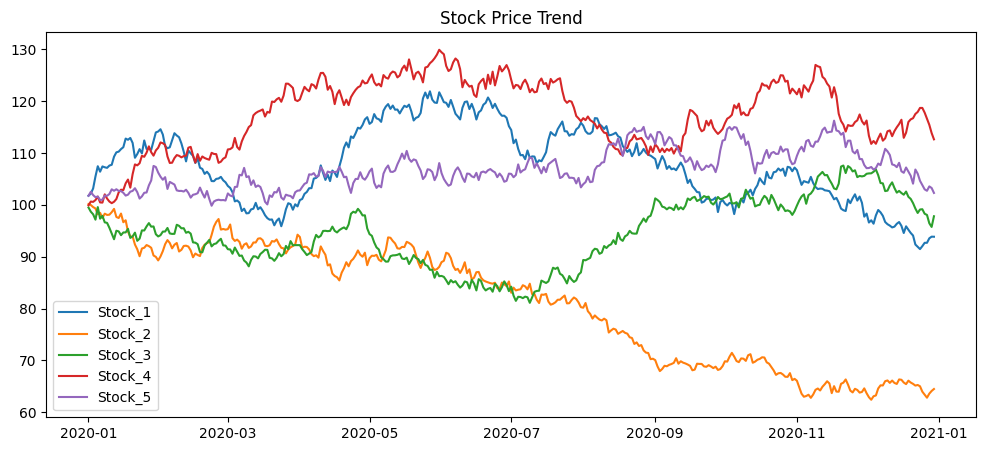

In [20]:
# Trend of all stocks
plt.figure(figsize=(12,5))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.legend()
plt.title('Stock Price Trend')
plt.show()

5. Correlation Heatmap

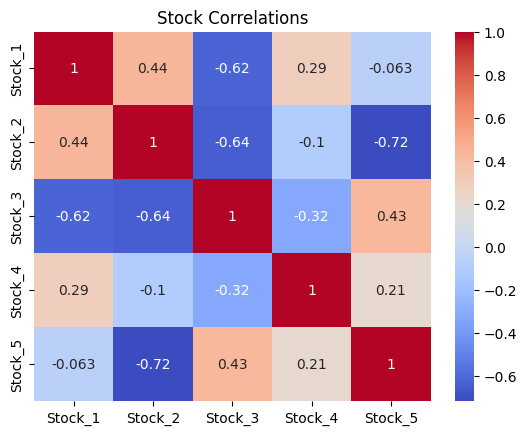

In [21]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm')
plt.title('Stock Correlations')
plt.show()

6. Creating Lag Features (Previous Day Prices)

In [22]:
for col in df.columns:
    df[f'{col}_prev_day'] = df[col].shift(1)
    df[f'{col}_prev_week'] = df[col].shift(7)

df = df.dropna()
df.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_1_prev_day,Stock_1_prev_week,Stock_2_prev_day,Stock_2_prev_week,Stock_3_prev_day,Stock_3_prev_week,Stock_4_prev_day,Stock_4_prev_week,Stock_5_prev_day,Stock_5_prev_week
2020-01-08,107.251404,98.306394,96.631181,102.026929,101.791802,107.413982,101.764052,97.485922,100.160928,97.888611,99.494642,100.441100,99.909756,101.006372,101.761266
2020-01-09,107.140700,98.061160,96.530353,101.215305,101.755418,107.251404,102.171269,98.306394,99.969968,96.631181,98.682973,102.026929,100.640755,101.791802,102.528643
2020-01-10,107.580618,98.109696,95.576631,100.641981,102.097333,107.140700,103.171258,98.061160,99.575237,96.530353,98.182139,101.215305,100.574847,101.755418,101.887811
2020-01-11,107.735581,98.594197,94.451093,100.332314,103.002417,107.580618,105.483215,98.109696,99.308641,95.576631,97.149381,100.641981,100.925017,102.097333,101.490049
2020-01-12,109.302351,99.228468,93.374165,100.602232,102.722115,107.735581,107.453175,98.594197,98.188428,94.451093,99.575396,100.332314,101.594411,103.002417,101.604283


7. Preparing X and y

In [23]:
target = 'Stock_1'

feature_cols = [col for col in df.columns if col != target]
X = df[feature_cols]
y = df[target]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (358, 14)
Target: (358,)


In [24]:
# Convert to numpy arrays
X = X.values
y = y.values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (358, 14)
y shape: (358,)


8. Train Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 286
Test size: 72


9. Training Model

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


10. Making Predictions

In [27]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

 11. Checking Accuracy

In [28]:
print("Training Set Performance:")
print(f"MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"RMSE: {mean_squared_error(y_train, y_pred_train)**0.5:.4f}")
print(f"R2 Score: {r2_score(y_train, y_pred_train):.4f}")

print("Test Set Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_test)**0.5:.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_test):.4f}")

Training Set Performance:
MAE: 0.8569
RMSE: 1.0596
R2 Score: 0.9749
Test Set Performance:
MAE: 0.7870
RMSE: 0.9517
R2 Score: 0.9585


12. Ploting Actual vs Predicted 

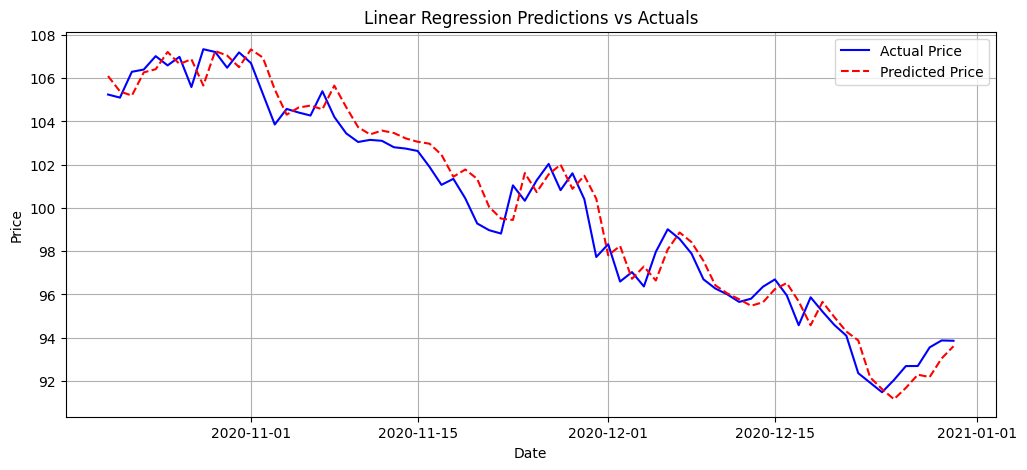

In [29]:
test_dates = df.index[-len(y_test):]

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test, label='Actual Price', color='blue')
plt.plot(test_dates, y_pred_test, label='Predicted Price', color='red', linestyle='--')
plt.title('Linear Regression Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

13. Predicting Next 30 Days 

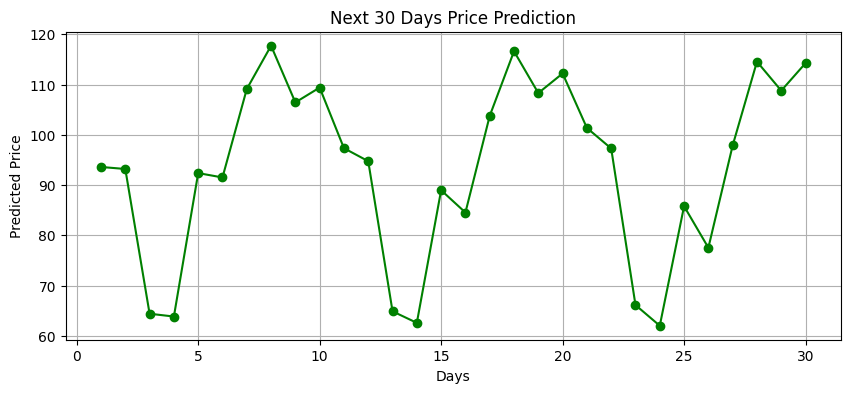

Day 1: $93.60
Day 2: $93.20
Day 3: $64.40
Day 4: $63.84
Day 5: $92.38


In [30]:
last = X[-1].copy()
future = []
for _ in range(30):
    p = model.predict([last])[0]
    future.append(p)
    last = np.roll(last, -1)
    last[-1] = p

plt.figure(figsize=(10,4))
plt.plot(range(1,31), future, 'o-', c='green')
plt.title('Next 30 Days Price Prediction')
plt.xlabel('Days')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

for i, p in enumerate(future[:5], 1):
    print(f"Day {i}: ${p:.2f}")